# Function 3

## Check sys.path

In [1]:
# Checking that PYTHONPATH has been set to include local modules and included with sys.path

import os
try:
    print(f'PYTHONPATH:\n{os.environ['PYTHONPATH'].split(os.pathsep)}')
except KeyError:
    pass

import sys
print(f'\nsys.path:\n{'\n'.join(sys.path)}')

PYTHONPATH:
['C:\\Users\\antho\\Git\\LearningPython\\']

sys.path:
C:\Users\antho\Git\LearningPython
C:\Users\antho\AppData\Local\Python\pythoncore-3.14-64\python314.zip
C:\Users\antho\AppData\Local\Python\pythoncore-3.14-64\DLLs
C:\Users\antho\AppData\Local\Python\pythoncore-3.14-64\Lib
C:\Users\antho\AppData\Local\Python\pythoncore-3.14-64

C:\Users\antho\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages


## Imports

In [2]:
# Load extension to auto re-import script changes without having to restart Python kernel 
%load_ext autoreload

# Set autoreload = 2 (reloads everything before every cell execution)
%autoreload 2

# Import scripts common across all BBOFunction notebooks. '%run' ensures variables/imports become part of this notebook's namespace
%run imports.py

## Function 3 Description

*You’re working on a drug discovery project, testing combinations of three compounds to create a new medicine.*

*Each experiment is ... a 3D array, where each row lists the amounts of the three compounds used. After each experiment, you record the number of adverse reactions.*

*Your goal is to minimise side effects; in this competition, it is framed as maximisation by optimising a transformed output (e.g. the negative of side effects).*

## BBO parameters

In [3]:
func_no = 3
sub_week = 13

display(Markdown(f'**function number:** {func_no}'))
display(Markdown(f'**submission week:** {sub_week}'))

**function number:** 3

**submission week:** 13

## Load data

In [4]:
initial_len, y_pred, x_dim, x_col_names, df = data_helper.get_data(func_no, sub_week)

initial data points: 15
initial max: -0.034835313350078584
submission data points: 12
current max: -0.007748010115508562 (from submission week: 10)
x_dim: 3


<br>**DataFrame:**

          x1        x2        x3         y
24  0.531716  0.508587  0.520560 -0.007748
18  0.416214  0.521707  0.518725 -0.008214
23  0.345979  0.513286  0.517784 -0.020800
17  0.444950  0.348788  0.558183 -0.032544
3   0.492581  0.611593  0.340176 -0.034835
25  0.870449  0.506473  0.519767 -0.035333
13  0.600097  0.725136  0.066089 -0.036378
26  0.475995  0.894744  0.512811 -0.042879
21  0.999999  0.550000  0.100000 -0.045110
10  0.220549  0.297825  0.343555 -0.046947
4   0.134622  0.219917  0.458206 -0.048008
14  0.965995  0.861120  0.566829 -0.056758
20  0.999999  0.999999  0.397311 -0.069079
22  0.000000  0.000000  0.525048 -0.080782
19  0.999999  0.999999  0.852992 -0.082500
1   0.242114  0.644074  0.272433 -0.087963
9   0.170477  0.697032  0.149169 -0.094190
11  0.666014  0.671985  0.246295 -0.105965
5   0.345523  0.941360  0.269363 -0.110621
2   0.534906  0.398501  0.173389 -0.111415
0   0.171525  0.343917  0.248737 -0.112122
7   0.645503  0.397143  0.919771 -0.113869
12  0.04680

### Manually omit columns or other data amends (if desired)

## Distance between x points

In [5]:
dists, min_dist, max_dist = distance_helper.distances_between_points(x = df[x_col_names].values)

#display(Markdown('**Distances between x points:**'))
#for row in dists:
#    print(f'{row}')

display(Markdown(f'**min_dist:** {min_dist}'))
display(Markdown(f'**max_dist:** {max_dist}'))

**min_dist:** 0.070744

**max_dist:** 1.451738

## Tune Gaussian Process surrogate model

### Setup hyperparameters to trial (kernels, x_tansform and y_transform)

In [6]:
kernels = gaussian_process_helper.get_kernels(x_dim)

print(kernels.keys())

dict_keys(['Matern 2.5', 'Matern 1.5', 'Matern 0.5', 'RBF', 'Rational Quad', 'Periodic', 'Locally Periodic', 'Linear + RBF', 'Matern 2.5 + WhiteK', 'Matern 1.5 + WhiteK', 'Matern 0.5 + WhiteK', 'RBF + WhiteK', 'Rational Quad + WhiteK', 'Periodic + WhiteK', 'Locally Periodic + WhiteK', 'Linear + RBF + WhiteK', 'Local Sens + Mat 2.5 + WhiteK', 'Ridge + RQ + WhiteK', 'Local Sens + Ridge + Mat 2.5 + WhiteK'])


In [7]:
y_transforms = transform_helper.get_y_transformers()

print(y_transforms.keys())

dict_keys(['none', 'scaled', 'power', 'pow-scaled', 'logshift', 'logshift-scaled'])


In [8]:
x_transforms = transform_helper.get_x_transformers()

print(x_transforms.keys())

dict_keys(['none', 'scaled'])


### Manually override hyperparameter options (if desired)

### Perform the hyperparameter tuning

In [9]:
df_tuning_results, model_dict = gaussian_process_helper.tune_gaussian_process_surrogate(
    df = df,
    x_col_names = x_col_names,
    kernels = kernels,
    y_transforms = y_transforms,
    x_transforms = x_transforms,
)


Matern 2.5, x:none, y:none...
         y_t    mean_t   resid_t     std_t    y_pred
24 -0.007748  0.001232  0.008980  0.007313  0.001232
18 -0.008214 -0.013272 -0.005058  0.003440 -0.013272
23 -0.020800 -0.012617  0.008184  0.005241 -0.012617
17 -0.032544 -0.052510 -0.019966  0.018461 -0.052510
3  -0.034835 -0.060941 -0.026106  0.035419 -0.060941
25 -0.035333 -0.063037 -0.027705  0.032341 -0.063037
13 -0.036378 -0.101188 -0.064811  0.037505 -0.101188
26 -0.042879 -0.014069  0.028810  0.037631 -0.014069
21 -0.045110 -0.026053  0.019057  0.072701 -0.026053
10 -0.046947 -0.050436 -0.003489  0.028779 -0.050436
4  -0.048008 -0.053361 -0.005353  0.028027 -0.053361
14 -0.056758 -0.053310  0.003448  0.054747 -0.053310
20 -0.069079 -0.032915  0.036164  0.078313 -0.032915
22 -0.080782 -0.075403  0.005379  0.051247 -0.075403
19 -0.082500 -0.025603  0.056897  0.103935 -0.025603
1  -0.087963 -0.104256 -0.016293  0.019215 -0.104256
9  -0.094190 -0.134858 -0.040668  0.054222 -0.134858
11 -0.105965 -0

C:\Users\antho\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__sigma_0 is close to the specified lower bound 1e-07. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


         y_t    mean_t   resid_t     std_t    y_pred
24  1.065582  0.982418 -0.083163  0.216055 -0.013890
18  1.059269  1.091413  0.032144  0.093333 -0.005840
23  0.888864  0.844519 -0.044345  0.133209 -0.024076
17  0.729860  0.783963  0.054103  0.517259 -0.028548
3   0.698839  0.320709 -0.378130  0.360787 -0.062764
25  0.692106  0.118239 -0.573867  0.828329 -0.077718
13  0.677955 -0.658031 -1.335986  0.662437 -0.135053
26  0.589928 -0.113210 -0.703138  0.879126 -0.094813
21  0.559724 -0.009957 -0.569681  1.055937 -0.087186
10  0.534850  0.115498 -0.419352  0.278465 -0.077920
4   0.520496  0.891550  0.371054  0.447341 -0.020602
14  0.402017  0.305193 -0.096824  0.731196 -0.063910
20  0.235207  0.145020 -0.090187  0.864980 -0.075740
22  0.076754 -0.183435 -0.260188  0.849060 -0.099999
19  0.053497 -0.282282 -0.335779  1.080209 -0.107300
1  -0.020469  0.287233  0.307702  0.382088 -0.065236
9  -0.104774 -0.567792 -0.463018  0.530394 -0.128388
11 -0.264206  0.687164  0.951370  0.488181 -0.

C:\Users\antho\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__sigma_0 is close to the specified lower bound 1e-07. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


         y_t    mean_t   resid_t     std_t    y_pred
24  1.065582  1.052256 -0.013326  0.165885 -0.008732
18  1.059269  1.069264  0.009994  0.072476 -0.007476
23  0.888864  0.876815 -0.012048  0.106704 -0.021690
17  0.729860  0.714011 -0.015849  0.476816 -0.033715
3   0.698839  0.325851 -0.372988  0.318596 -0.062384
25  0.692106  0.319259 -0.372847  0.753185 -0.062871
13  0.677955 -0.572806 -1.250760  0.656099 -0.128758
26  0.589928 -0.016902 -0.606830  0.880565 -0.087699
21  0.559724  0.539045 -0.020679  1.078044 -0.046638
10  0.534850  0.104940 -0.429911  0.268835 -0.078700
4   0.520496  0.914660  0.394164  0.416271 -0.018895
14  0.402017  0.391498 -0.010519  0.744469 -0.057535
20  0.235207  0.352710  0.117504  0.897666 -0.060400
22  0.076754 -0.275446 -0.352200  0.871245 -0.106795
19  0.053497 -0.117469 -0.170966  1.258118 -0.095127
1  -0.020469  0.298449  0.318918  0.358366 -0.064408
9  -0.104774 -0.625833 -0.521058  0.532817 -0.132675
11 -0.264206  0.555344  0.819550  0.447957 -0.

C:\Users\antho\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__sigma_0 is close to the specified lower bound 1e-07. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


         y_t    mean_t   resid_t     std_t    y_pred
24  0.591533  0.569746 -0.021788  0.095337 -0.011444
18  0.589044  0.604990  0.015946  0.039554 -0.005155
23  0.520791  0.491848 -0.028943  0.059184 -0.025889
17  0.455222  0.561133  0.105911  0.306730 -0.009605
3   0.442209  0.296567 -0.145642  0.175368 -0.058507
25  0.439374  0.331758 -0.107616  0.559120 -0.042218
13  0.433406 -0.234971 -0.668377  0.484512 -0.131048
26  0.395927  0.026096 -0.369831  0.712958 -0.085059
21  0.382925  0.585111  0.202186  0.973484  0.031365
10  0.372162  0.076743 -0.295419  0.176424 -0.093138
4   0.365928  0.780554  0.414626  0.265551  0.032296
14  0.313814  0.466604  0.152790  0.606684 -0.016070
20  0.238378  0.110233 -0.128144  0.829973 -0.065569
22  0.164351 -0.081243 -0.245594  0.733946 -0.100206
19  0.153281 -0.262939 -0.416221  1.282050 -0.091432
1   0.117719  0.368067  0.250348  0.209674 -0.046015
9   0.076502 -0.426624 -0.503126  0.378614 -0.158062
11 -0.003525  0.288399  0.291924  0.281899 -0.

C:\Users\antho\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__k1__k1__constant_value is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\antho\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__k1__k2__length_scale is close to the specified lower bound 1e-07. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


## Analytical Leave-One-Out Cross-Validation (LOOCV) Model Results

In [10]:
# Sort df_tuning_results:
# Mean-Square_Error (MSE) - The "best" kernel is the one with the lowest MSE    
# Log-Marginal Likelihood (LML) - The "best" kernel is the one with the highest LML
sort_columns = [Y_SMSE_TOP, Y_SMSE, Z_SMSE, LML]
sort_orders  = [      True,   True,   True, False]

#sort_columns = [Y_SMSE, Z_SMSE, LML]
#sort_orders  = [  True,   True, False]

df_tuning_results_sorted = df_tuning_results.sort_values(by=sort_columns, ascending=sort_orders)

# Format numeric display columns
display_cols = [MODEL, Z_SMSE, Y_SMSE, Y_SMSE_TOP, LML, KERNEL_PARAMS ]
for col in display_cols:
    df_tuning_results_sorted[col] = df_tuning_results_sorted[col].apply(format_sig_figs)

print(df_tuning_results_sorted[display_cols].to_string(index=False))

                                                             Model   Z_SMSE   Y_SMSE Y_SMSE_TOP      LML                                                                                                                                                              Kernel_Params
       Local Sens + Ridge + Mat 2.5 + WhiteK, x:none, y:pow-scaled 0.338304 0.623809 0.00855895 -28.5658  0.441**2 * Matern(len_scale=[0.188, 0.288, 0.478], nu=1.5) + DotProduct(sigma_0=0.000687) + 0.86**2 * Matern(len_scale=[10, 0.779, 0.0742], nu=2.5) + WhiteK(noise=1e-07)
               Local Sens + Mat 2.5 + WhiteK, x:none, y:pow-scaled 0.345746 0.671857 0.00969864 -27.7914                                 0.404**2 * Matern(len_scale=[0.166, 0.261, 0.498], nu=1.5) + 0.946**2 * Matern(len_scale=[10, 0.743, 0.082], nu=2.5) + WhiteK(noise=1e-07)
                         Linear + RBF + WhiteK, x:none, y:logshift   1.2947  2.58618  0.0120281 -1.86887                                                                    

## LOOCV Detailed Results for best model (Optionally override auto selected best model)

In [11]:
best_model_name = df_tuning_results_sorted[MODEL].iloc[0]

# Manually overriding best_model (optional)
override_model_name = None

if not override_model_name is None:
    display(Markdown(f'<span style="color:red">**Warning: Manually overriding best model from "{best_model_name}" to "{override_model_name}"**</span>'))
    best_model_name = override_model_name
    
best_model_dict = model_dict[best_model_name]
best_model = best_model_dict[MODEL]
x_transform = best_model_dict[X_TRANSFORM]
y_transform = best_model_dict[Y_TRANSFORM]

display(Markdown(f'<br>**Best model:**<br>{best_model_name}'))

params_str = extract_optimised_kernel_params_str(best_model)
display(Markdown(f'**Optimised parameters:**'))
print(params_str) # Own print() since it contains **

best_loocv_results = best_model_dict[LOOCV]

# Add the best model LOOCV results to df for easier display 
for label, content in best_loocv_results.items():
    df[label] = content

display(Markdown(f'<br>**LOOCV Predictions using best model:**<br>'))
print(df)

<br>**Best model:**<br>Local Sens + Ridge + Mat 2.5 + WhiteK, x:none, y:pow-scaled

**Optimised parameters:**

0.441**2 * Matern(len_scale=[0.188, 0.288, 0.478], nu=1.5) + DotProduct(sigma_0=0.000687) + 0.86**2 * Matern(len_scale=[10, 0.779, 0.0742], nu=2.5) + WhiteK(noise=1e-07)


<br>**LOOCV Predictions using best model:**<br>

          x1        x2        x3         y       y_t    mean_t   resid_t  \
24  0.531716  0.508587  0.520560 -0.007748  1.838324  1.649845 -0.188479   
18  0.416214  0.521707  0.518725 -0.008214  1.820389  1.599157 -0.221232   
23  0.345979  0.513286  0.517784 -0.020800  1.365146  1.614967  0.249820   
17  0.444950  0.348788  0.558183 -0.032544  0.986513  0.716645 -0.269868   
3   0.492581  0.611593  0.340176 -0.034835  0.917376  0.963128  0.045752   
25  0.870449  0.506473  0.519767 -0.035333  0.902564  1.169682  0.267118   
13  0.600097  0.725136  0.066089 -0.036378  0.871654  0.166232 -0.705423   
26  0.475995  0.894744  0.512811 -0.042879  0.685981  1.000854  0.314873   
21  0.999999  0.550000  0.100000 -0.045110  0.624804  0.354032 -0.270772   
10  0.220549  0.297825  0.343555 -0.046947  0.575359  0.281220 -0.294139   
4   0.134622  0.219917  0.458206 -0.048008  0.547205  0.352126 -0.195079   
14  0.965995  0.861120  0.566829 -0.056758  0.324985  0.367094  0.042109   
20  0.999999

## y and y_t (y transformed) plots

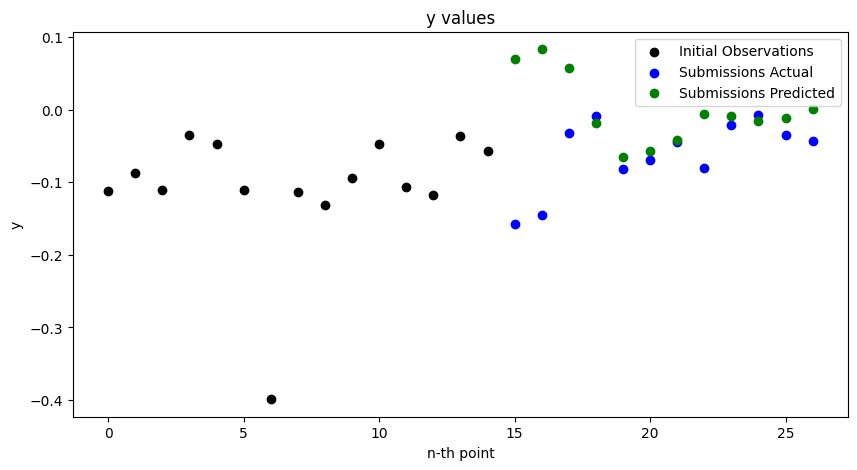

In [12]:
plot_helper.sequence_plot(df["y"], initial_len, y_pred)

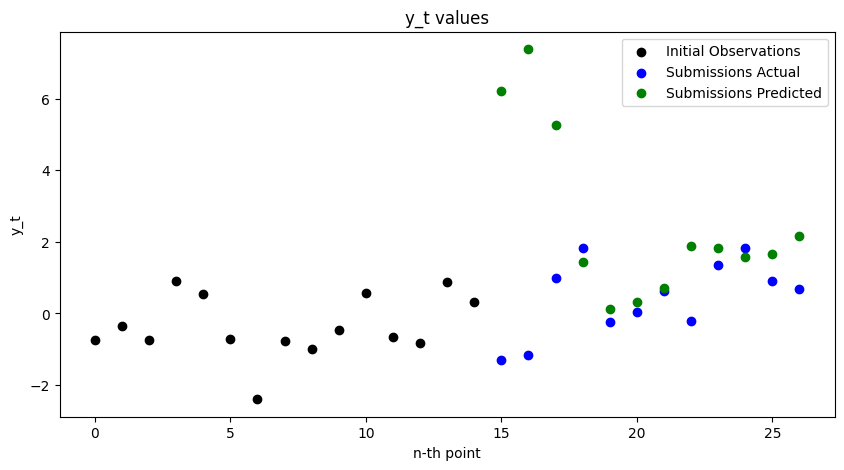

In [13]:
y_t_pred = y_transform.transform(y_pred)
plot_helper.sequence_plot(df["y_t"], initial_len, y_t_pred)

## Determine next evaluation point

### Create grid

In [14]:
x_grid = grid_helper.hypercube_grid([40, 40, 100], x_col_names)

#print(x_grid[0:5])

len(x_grid): 169781


### Maximise UCB and EI acquisition functions

In [15]:
# Small xi (0.0 – 0.01) - Exploitation dominant
# Moderate xi (0.01 – 0.1) - Balanced
# Large xi (0.5+) Strong exploration
ei_xis = [ 2, 1, 0.5, 0.1, 0.05, 0.01, 0.005, 0.001, 0 ]
ucb_betas = [ 10, 5, 2, 1, 0.5, 0.1, 0.05, 0.01, 0 ]
acq_fns = acquisition_fns_helper.get_acq_fns(df, y_transform, ei_xis = ei_xis, ucb_betas = ucb_betas)

# Bespoke bounds to force suggested next x near current x_best:
override_bounds = None # E.g. [(0.5, 0.9), (0.1, 0.4), ...]

if not override_bounds is None:
    display(Markdown(f'<span style="color:red">**Warning: Manually overriding acquisition function optimisation bounds to "{override_bounds}"**</span>'))

df_acq_results = acquisition_fns_helper.determine_next_eval_points(df, best_model, x_grid, x_col_names, x_transform, y_transform, x_dim, acq_fns, bounds = override_bounds, opt_trials=1000)

EI trans space (xi=2)...
Acq Fn([0.999999   0.         0.02739737]) = 2.036442749290613e-05, distance: 0.42939818193268436, y_t_best: [0.3197814], y_best: [-0.06563744]
EI trans space (xi=1)...
Acq Fn([0.999999   0.         0.03938436]) = 0.0011094268191475711, distance: 0.42397877413128976, y_t_best: [0.39769272], y_best: [-0.06137416]
EI trans space (xi=0.5)...
Acq Fn([0.999999  0.        0.0445931]) = 0.005743238797717591, distance: 0.42170836328761374, y_t_best: [0.42595398], y_best: [-0.05982424]
EI trans space (xi=0.1)...
Acq Fn([0.4727471  0.49913194 0.49427126]) = 0.0717055577919198, distance: 0.06525202978771119, y_t_best: [1.86770428], y_best: [-0.007202]
EI trans space (xi=0.05)...
Acq Fn([0.47265161 0.5014022  0.49764828]) = 0.09391544371293435, distance: 0.06357449837819225, y_t_best: [1.88867791], y_best: [-0.00662413]
EI trans space (xi=0.01)...
Acq Fn([0.47255313 0.50408322 0.50118801]) = 0.11607878684019045, distance: 0.061581178419838345, y_t_best: [1.90770746], y_bes

### Display the acquisition function results

In [16]:
display(Markdown(f'<br>**EXISTING BEST:**'))
print(f'Actual y: {df['y'].iloc[0]}\nActual y_t: {df['y_t'].iloc[0]}\nx: {df[x_col_names].iloc[0].values}')

y_t_mean, y_t_std = best_model.predict(np.atleast_2d(df[x_col_names].iloc[0].values), return_std=True)
y_mean, y_std = y_transform.inverse_transform_dist(y_t_mean, y_t_std)

display(Markdown(f'<br>**Model\'s [{best_model_name}] prediction at x corresponding to the best y.**'))
print(f'NB. the model was already trained using this x point. This is just a sense check for modelling accuracy rather than predictive ability.')
print(f'y_t_mean: {y_t_mean}, y_t_std: {y_t_std}\ny_mean: {y_mean}\n')

# Add a y_mean ranking
df_acq_results['y_mean rank'] = df_acq_results['y_mean'].rank(ascending=False, method='min').astype(int)

display(Markdown(f'<br>**FUNCTION {func_no} SUBMISSION WEEK {sub_week}:**<br>'))
print(df_acq_results.to_string(index=False))

<br>**EXISTING BEST:**

Actual y: -0.007748010115508562
Actual y_t: 1.8383240602353776
x: [0.531716 0.508587 0.52056 ]


<br>**Model's [Local Sens + Ridge + Mat 2.5 + WhiteK, x:none, y:pow-scaled] prediction at x corresponding to the best y.**

NB. the model was already trained using this x point. This is just a sense check for modelling accuracy rather than predictive ability.
y_t_mean: [1.8383238], y_t_std: [0.00044721]
y_mean: [-0.00774802]



<br>**FUNCTION 3 SUBMISSION WEEK 13:**<br>

                     acq_fn         ['x1', 'x2', 'x3']  distance  y_t_mean    y_mean  y_mean rank
      EI trans space (xi=2) 0.999999-0.000000-0.027397  0.429398  0.319781 -0.065637           16
      EI trans space (xi=1) 0.999999-0.000000-0.039384  0.423979  0.397693 -0.061374           15
    EI trans space (xi=0.5) 0.999999-0.000000-0.044593  0.421708  0.425954 -0.059824           14
    EI trans space (xi=0.1) 0.472747-0.499132-0.494271  0.065252  1.867704 -0.007202           11
   EI trans space (xi=0.05) 0.472652-0.501402-0.497648  0.063574  1.888678 -0.006624           10
   EI trans space (xi=0.01) 0.472553-0.504083-0.501188  0.061581  1.907707 -0.006099            9
  EI trans space (xi=0.005) 0.472538-0.504499-0.501708  0.061303  1.910210 -0.006030            8
  EI trans space (xi=0.001) 0.472525-0.504848-0.502140  0.061075  1.912223 -0.005974            7
      EI trans space (xi=0) 0.472521-0.504938-0.502250  0.061017  1.912728 -0.005960            6
  UCB trans space (b

## Manually calculating the prediction at an x point (Helper method)